In [24]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv

In [25]:
load_dotenv()
llm = ChatOpenAI()
parser = StrOutputParser()

In [26]:
class BlogState(TypedDict):
  title: str
  outline: str
  detailed_summary: str

In [27]:
def gen_outline(state: BlogState):
  title = state.get('title', '')
  prompt = PromptTemplate(template='generate an outline based on the title:\n{title}', input_variables= ['title'])
  chain = prompt | llm | parser
  outline = chain.invoke({'title': title})

  return {'outline': outline}

In [28]:
def gen_blog(state: BlogState):
  outline = state.get('outline', '')
  prompt = PromptTemplate(template='generate a detailed blog based on the outline:\n{outline}', input_variables= ['outline'])

  chain = prompt | llm | parser
  blog = chain.invoke({'outline': outline})
  
  return {'detailed_summary': blog}

In [29]:
graph = StateGraph(BlogState)

graph.add_node('gen_outline', gen_outline)
graph.add_node('gen_blog', gen_blog)

graph.add_edge(START, 'gen_outline')
graph.add_edge('gen_outline', 'gen_blog')
graph.add_edge('gen_blog', END)

workflow = graph.compile()

In [30]:
initial_state = {
  'title': 'Role of Agentic Ai in human life'
}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'Role of Agentic Ai in human life', 'outline': 'I. Introduction\n   A. Definition of Agentic AI\n   B. Overview of AI technology\n   C. Importance of AI in modern society\n\nII. The role of Agentic AI in enhancing human productivity\n   A. Automation of repetitive tasks\n   B. Decision making support\n   C. Assistance in complex problem solving\n\nIII. The role of Agentic AI in improving human creativity\n   A. AI-generated content in the arts\n   B. AI tools for design and innovation\n   C. Collaborative creativity with AI\n\nIV. The role of Agentic AI in healthcare\n   A. AI diagnostic tools\n   B. AI in drug discovery and development\n   C. AI-enhanced patient care and monitoring\n\nV. The ethical implications of Agentic AI in human life\n   A. Privacy concerns\n   B. Bias and discrimination in AI algorithms\n   C. Autonomous decision making by AI\n\nVI. The future of Agentic AI and its impact on human society\n   A. Potential benefits of AI advancements\n   B. Potential r

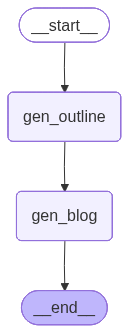

In [31]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())